### Transformer Model Fine Tuning

Fine tune transformer model for follow-through prediction using labeled VWAP Reclaim entries. 
- P(follow_through) - whether trade will move >= 3.0 ATR in 24 bars.

In [16]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import math
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import precision_score, recall_score

For fine tuning, smaller batch sizes will be utilized. Two-phase fine tuning approach will be used.
- Phase 1: freeze encoder, train only the classification head
- Phase 2: unfreeze encoder, fine-tune everything with lower learning rate

Due to class imbalance, weights will be calculated and assigned.

In [2]:
# config
SEQ_LEN    = 48
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 2
D_FF       = 256
DROPOUT    = 0.1
SYMBOL_EMB = 8
SYMBOLS    = ['COIN', 'NVDA', 'OKLO', 'PLTR', 'TSLA']

# fine tuning specs
BATCH_SIZE    = 32
PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 30
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-4
PATIENCE      = 7
POS_WEIGHT    = 1156 / 460
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# load scaler stats
with open('feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

FEATURE_COLS = scaler['feature_cols']
feat_mean    = scaler['mean']
feat_std     = scaler['std']
N_FEATURES   = len(FEATURE_COLS)
INPUT_DIM    = N_FEATURES + SYMBOL_EMB

print(f"Device      : {DEVICE}")
print(f"Features    : {N_FEATURES}")
print(f"POS_WEIGHT  : {POS_WEIGHT:.3f}")

Device      : cuda
Features    : 16
POS_WEIGHT  : 2.513


In [4]:
# load 5M data and entries

# raw 5M price data
df = pd.read_csv('multiasset_5m_rth_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['ts_ny'] = df['timestamp'].dt.tz_convert('America/New_York')
df['session_date'] = df['ts_ny'].dt.date
df['date_ny'] = pd.to_datetime(df['session_date'])
df['symbol_id'] = df['symbol'].map({s: i for i, s in enumerate(SYMBOLS)})

# vwap reclaim entries
entries = pd.read_csv('multiasset_labeled_entries.csv')
entries['date_ny'] = pd.to_datetime(entries['date_ny'])

# validate splits
print("Entry split distribution:")
print(entries['split'].value_counts().sort_index())

print(f"\n5M data shape : {df.shape}")
print(f"Entries shape  : {entries.shape}")

Entry split distribution:
split
test      251
train    1112
val       253
Name: count, dtype: int64

5M data shape : (171692, 31)
Entries shape  : (1616, 40)


In [5]:
entries.columns.tolist()

['symbol',
 'timestamp',
 'date_ny',
 'i_signal',
 'i_entry',
 'ts_signal',
 'ts_entry',
 'entry_price',
 'entry_atr',
 'side',
 'split',
 'ret_1',
 'ret_3',
 'ret_6',
 'ret_12',
 'ret_18',
 'ret_24',
 'atr_12',
 'atr_pct_12',
 'vwap_dist',
 'vwap_dist_atr',
 'vol_ratio_18',
 'rv_12',
 'range_pct',
 'body_pct',
 'upper_wick_pct',
 'lower_wick_pct',
 'tod_sin',
 'tod_cos',
 'mfe_atr',
 'mae_atr',
 'time_to_peak_bars',
 'follow_through',
 'R_scalp',
 'exit_reason_scalp',
 'R_hold',
 'exit_reason_hold',
 'R_oracle',
 'risk_oracle',
 'exit_reason_oracle']

Extract entry sequence from 5M data. For each vwap reclaim entry, extract 48 bars immediately before entry from the same stock and session. If sequence is too short, left padd with zeros. loaded scaler normalization will be applied.

In [6]:
# extract entry sequence
def extract_entry_sequence(df, i_entry, symbol, date_ny, seq_len=SEQ_LEN):
    start_idx = max(0, i_entry - seq_len - 10)
    window    = df.iloc[start_idx : i_entry]
    window    = window[
        (window['symbol']  == symbol) &
        (window['date_ny'] == date_ny)
    ]
    window = window.tail(seq_len)
    # extract and normalize features
    feats = window[FEATURE_COLS].values.astype(np.float32)
    feats = (feats - feat_mean.values) / feat_std.values
    feats = np.nan_to_num(feats, nan=0.0)
    feats = np.clip(feats, -5.0, 5.0)
    # left pad with zeros if sequence is too short
    if len(feats) < seq_len:
        pad   = np.zeros((seq_len - len(feats), N_FEATURES), dtype=np.float32)
        feats = np.vstack([pad, feats])

    return feats

In [7]:
# extract sequence for all vwap reclaim entries
sequences  = []
symbol_ids = []
skipped    = 0

for _, row in entries.iterrows():
    i_entry  = int(row['i_entry'])
    symbol   = row['symbol']
    date_ny  = row['date_ny']
    sym_id   = SYMBOLS.index(symbol)

    seq = extract_entry_sequence(df, i_entry, symbol, date_ny)

    if seq.shape != (SEQ_LEN, N_FEATURES):
        skipped += 1
        continue

    sequences.append(seq)
    symbol_ids.append(sym_id)

sequences  = np.array(sequences,  dtype=np.float32)
symbol_ids = np.array(symbol_ids, dtype=np.int64)

print(f"Sequences extracted : {len(sequences):,}")
print(f"Skipped             : {skipped}")
print(f"Sequences shape     : {sequences.shape}")
pad_count = sum(
    1 for seq in sequences if (seq[:SEQ_LEN//4] == 0).all()
)
print(f"~{pad_count} sequences with leading zeros")

Sequences extracted : 1,616
Skipped             : 0
Sequences shape     : (1616, 48, 16)
~937 sequences with leading zeros


Create fine tuning dataset with 48 bars, stock id, and follow through label. 

In [9]:
# create entry sequence data
class EntrySequenceDataset(Dataset):
    def __init__(self, entries_df, sequences, symbol_ids):
        self.sequences  = sequences
        self.symbol_ids = symbol_ids
        self.labels     = entries_df['follow_through'].values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx]),
            torch.tensor(self.symbol_ids[idx]),
            torch.tensor(self.labels[idx])
        )

# split data
train_mask = entries['split'] == 'train'
val_mask   = entries['split'] == 'val'
test_mask  = entries['split'] == 'test'

# create datasets
train_dataset = EntrySequenceDataset(
    entries[train_mask].reset_index(drop=True),
    sequences[train_mask.values],
    symbol_ids[train_mask.values]
)
val_dataset = EntrySequenceDataset(
    entries[val_mask].reset_index(drop=True),
    sequences[val_mask.values],
    symbol_ids[val_mask.values]
)
test_dataset = EntrySequenceDataset(
    entries[test_mask].reset_index(drop=True),
    sequences[test_mask.values],
    symbol_ids[test_mask.values]
)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train : {len(train_dataset):,} entries  FT rate: {train_dataset.labels.mean():.1%}")
print(f"Val   : {len(val_dataset):,} entries  FT rate: {val_dataset.labels.mean():.1%}")
print(f"Test  : {len(test_dataset):,} entries  FT rate: {test_dataset.labels.mean():.1%}")
print(f"\nTrain batches : {len(train_loader)}")

Train : 1,112 entries  FT rate: 28.0%
Val   : 253 entries  FT rate: 34.0%
Test  : 251 entries  FT rate: 25.1%

Train batches : 35


Create fine tuning model. Model architecture will be identical to pre-train model architecture. Classification head will be attached for follow-through-prediction.

In [10]:
# sinusoida encoding
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# core encoder
class BarTransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.symbol_embedding = nn.Embedding(len(SYMBOLS), SYMBOL_EMB)
        self.input_proj       = nn.Linear(INPUT_DIM, D_MODEL)
        self.pos_encoding     = SinusoidalPositionalEncoding(D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=N_LAYERS, enable_nested_tensor=False
        )
        self.norm = nn.LayerNorm(D_MODEL)

    def forward(self, x, symbol_id):
        sym_emb = self.symbol_embedding(symbol_id)
        sym_emb = sym_emb.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, sym_emb], dim=-1)
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        return self.norm(x)

# follow through classifier
class FollowThroughClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = BarTransformerEncoder()
        self.classifier = nn.Sequential(
            nn.Linear(D_MODEL, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, symbol_id):
        enc_out = self.encoder(x, symbol_id)
        pooled  = enc_out.mean(dim=1)
        logit   = self.classifier(pooled)
        return logit.squeeze(-1) 

In [12]:
# load pre-trained encoder weights
model = FollowThroughClassifier().to(DEVICE)
model.encoder.load_state_dict(
    torch.load('transformer_encoder_pretrained.pt', map_location=DEVICE)
)

total_params    = sum(p.numel() for p in model.parameters())
encoder_params  = sum(p.numel() for p in model.encoder.parameters())
head_params     = sum(p.numel() for p in model.classifier.parameters())

print(f"\nTotal params     : {total_params:,}")
print(f"Encoder params   : {encoder_params:,}")
print(f"Classifier head  : {head_params:,}")

# loss function with class weights
pos_weight = torch.tensor([POS_WEIGHT]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"\npos_weight={POS_WEIGHT:.3f}")


Total params     : 103,849
Encoder params   : 101,736
Classifier head  : 2,113

pos_weight=2.513


Two phase fine tuning starting with phase 1 by freezing encoder to train classifier head and phase 2 unfreezing encoder to fine tune everything at lower learning rate.

In [13]:
# epoch runner
def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    # track gradients during training
    with torch.set_grad_enabled(train):
        for x_batch, sid_batch, y_batch in loader:
            x_batch   = x_batch.to(DEVICE)
            sid_batch = sid_batch.to(DEVICE)
            y_batch   = y_batch.to(DEVICE)

            # forward pass
            logits = model(x_batch, sid_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            # convert logits to binary preds
            total_loss += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend((probs > 0.5).astype(int))
            all_labels.extend(y_batch.cpu().numpy().astype(int))

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, f1

# train
def train_phase(phase, epochs, lr, freeze_encoder):
    print(f"Phase {phase} — encoder {'FROZEN' if freeze_encoder else 'UNFROZEN'}  LR={lr}")
    print(f"{'Epoch':>6} {'Train Loss':>11} {'Train F1':>10} {'Val Loss':>10} {'Val F1':>8}")
    # freeze or unfreeze encoder
    for param in model.encoder.parameters():
        param.requires_grad = not freeze_encoder

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/10)

    best_val_loss    = float('inf')
    patience_counter = 0
    # run training epoch and val epoch
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = run_epoch(train_loader, model, criterion, optimizer, train=True)
        val_loss,   val_f1   = run_epoch(val_loader,   model, criterion, train=False)
        scheduler.step()

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'follow_through_classifier.pt')
        else:
            patience_counter += 1

        print(f"{epoch:>6} {train_loss:>11.4f} {train_f1:>10.4f} {val_loss:>10.4f} {val_f1:>8.4f}")
        # early stopping
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    print(f"Best val loss: {best_val_loss:.4f}")

# run phase 1 and phase 2
train_losses_p1, val_losses_p1 = [], []
train_losses_p2, val_losses_p2 = [], []

train_phase(phase=1, epochs=PHASE1_EPOCHS, lr=PHASE1_LR, freeze_encoder=True)
train_phase(phase=2, epochs=PHASE2_EPOCHS, lr=PHASE2_LR, freeze_encoder=False)

print("\nmodel saved to follow_through_classifier.pt")

Phase 1 — encoder FROZEN  LR=0.001
 Epoch  Train Loss   Train F1   Val Loss   Val F1
     1      0.9813     0.3915     1.0430   0.2778
     2      0.9556     0.4508     1.0282   0.4296
     3      0.9384     0.4641     0.9979   0.5498
     4      0.9220     0.4853     1.0117   0.4789
     5      0.9143     0.4703     0.9994   0.5161
     6      0.8940     0.5111     0.9864   0.5497
     7      0.8886     0.5095     0.9882   0.5488
     8      0.8837     0.4970     0.9850   0.5542
     9      0.8839     0.5145     0.9896   0.5283
    10      0.8809     0.4992     0.9788   0.5476
    11      0.8884     0.5094     0.9723   0.5393
    12      0.8733     0.5036     0.9760   0.5412
    13      0.8778     0.5184     0.9800   0.5366
    14      0.8763     0.5140     0.9832   0.5342
    15      0.8774     0.5221     0.9732   0.5318
    16      0.8806     0.5173     0.9841   0.5342
    17      0.8759     0.5109     0.9796   0.5333
    18      0.8765     0.4985     0.9766   0.5476

Early stopping

Evaluate against test dataset. Load best model weights and evaluate on test hold out dataset. Focus will be on precision as in trading, false positives are costly.

In [14]:
# load model and evaluate
model.load_state_dict(torch.load('follow_through_classifier.pt', map_location=DEVICE))
model.eval()

all_logits, all_probs, all_preds, all_labels = [], [], [], []

with torch.no_grad():
    for x_batch, sid_batch, y_batch in test_loader:
        x_batch   = x_batch.to(DEVICE)
        sid_batch = sid_batch.to(DEVICE)

        logits = model(x_batch, sid_batch)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_logits.extend(logits.cpu().numpy())
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy().astype(int))

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

all_preds = (all_probs > 0.5).astype(int)

print(f"\n{classification_report(all_labels, all_preds, target_names=['Scalp','Hold'], digits=3)}")
print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")


              precision    recall  f1-score   support

       Scalp      0.849     0.750     0.797       188
        Hold      0.447     0.603     0.514        63

    accuracy                          0.713       251
   macro avg      0.648     0.677     0.655       251
weighted avg      0.748     0.713     0.726       251

ROC-AUC : 0.7530


Due to class imbalance between scalp vs hold, accuracy is not a good metric to follow here. An ROC-AUC of 0.75 means the model has an ability to separate classes.

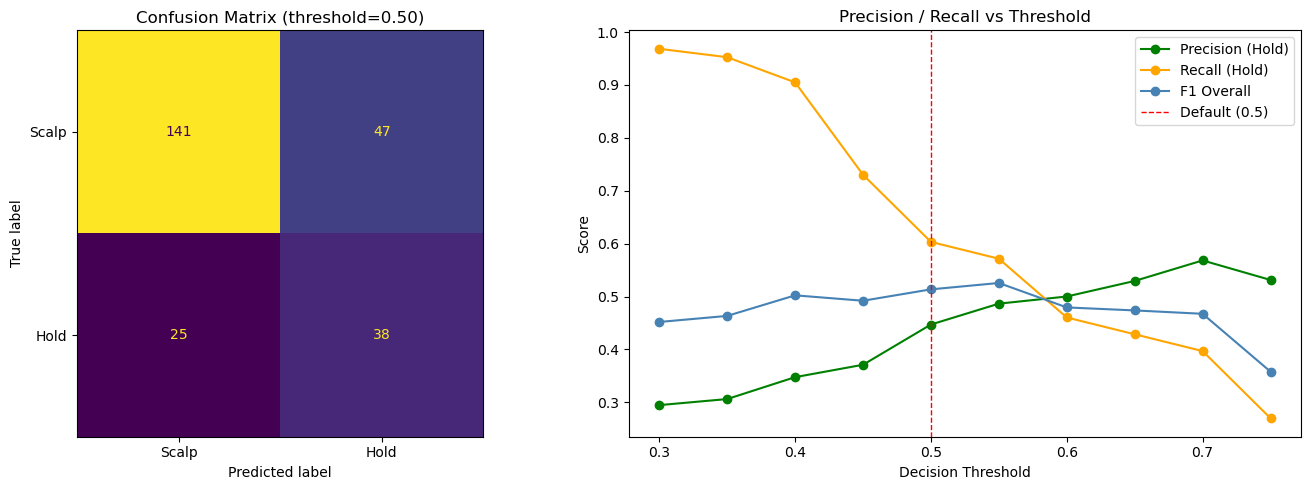

In [17]:
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Scalp','Hold']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (threshold=0.50)')

# precision vs recall tradeoff
thresholds  = np.arange(0.3, 0.8, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (all_probs > t).astype(int)
    precisions.append(f1_score(all_labels, preds, pos_label=1,
                               zero_division=0, average=None)[1] if preds.sum() > 0 else 0)
    recalls.append(f1_score(all_labels, preds, pos_label=1,
                            zero_division=0, average='macro'))
    f1s.append(f1_score(all_labels, preds, zero_division=0))

prec_vals = [precision_score(all_labels, (all_probs>t).astype(int),
             pos_label=1, zero_division=0) for t in thresholds]
rec_vals  = [recall_score(all_labels, (all_probs>t).astype(int),
             pos_label=1, zero_division=0) for t in thresholds]
f1_vals   = [f1_score(all_labels, (all_probs>t).astype(int),
             zero_division=0) for t in thresholds]

axes[1].plot(thresholds, prec_vals, marker='o', label='Precision (Hold)', color='green')
axes[1].plot(thresholds, rec_vals,  marker='o', label='Recall (Hold)',    color='orange')
axes[1].plot(thresholds, f1_vals,   marker='o', label='F1 Overall',       color='steelblue')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='Default (0.5)')
axes[1].set_title('Precision / Recall vs Threshold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# tradeoff table
print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Hold Calls':>12}")
for t, p, r, f in zip(thresholds, prec_vals, rec_vals, f1_vals):
    n_hold = (all_probs > t).sum()
    print(f"{t:>10.2f} {p:>10.3f} {r:>8.3f} {f:>8.3f} {n_hold:>12}")


 Threshold  Precision   Recall       F1   Hold Calls
      0.30      0.295    0.968    0.452          207
      0.35      0.306    0.952    0.463          196
      0.40      0.348    0.905    0.502          164
      0.45      0.371    0.730    0.492          124
      0.50      0.447    0.603    0.514           85
      0.55      0.486    0.571    0.526           74
      0.60      0.500    0.460    0.479           58
      0.65      0.529    0.429    0.474           51
      0.70      0.568    0.397    0.467           44
      0.75      0.531    0.270    0.358           32


Generate predictions for all vwap reclaim trades and save probabilities for backtesting. 0.60 threshold will be used as precision crosses over 50% which means model is right more than wrong on hold calls. 

In [21]:
# generate predictions
OPERATING_THRESHOLD = 0.60

full_dataset = EntrySequenceDataset(
    entries.reset_index(drop=True),
    sequences,
    symbol_ids
)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_probs_full = []

with torch.no_grad():
    for x_batch, sid_batch, _ in full_loader:
        x_batch   = x_batch.to(DEVICE)
        sid_batch = sid_batch.to(DEVICE)
        logits    = model(x_batch, sid_batch)
        probs     = torch.sigmoid(logits).cpu().numpy()
        all_probs_full.extend(probs)

all_probs_full = np.array(all_probs_full)

# save predictions
entries['p_follow_through']   = all_probs_full
entries['pred_follow_through'] = (all_probs_full >= OPERATING_THRESHOLD).astype(int)

output_cols = [
    'symbol', 'timestamp', 'date_ny', 'ts_entry',
    'entry_price', 'entry_atr', 'split',
    'follow_through',
    'p_follow_through', 'pred_follow_through',
    'mfe_atr', 'mae_atr',
    'R_scalp', 'exit_reason_scalp',
    'R_hold',  'exit_reason_hold',
    'R_oracle', 'risk_oracle', 'exit_reason_oracle'
]

entries[output_cols].to_csv('entry_predictions.csv', index=False)

print(f"\nPrediction distribution by split:")
print(entries.groupby('split')['pred_follow_through'].agg(['sum','count','mean']).round(3))


Prediction distribution by split:
       sum  count   mean
split                   
test    58    251  0.231
train  321   1112  0.289
val     70    253  0.277
